## Performance comparison of triangular matrix inverse

> The goal is to understand the "peak performance" of Ascend for AIV / AIC triangular inverse methods.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 11
plt.rcParams['lines.linewidth'] = 2.
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["s", "^", "v", "<", ">", "o", "X"]

_SNS_PARAMS = {"hue":'inverse_type', "style":'inverse_type', "markers":_MARKERS, "dashes":True}

PREFIX_PATH = "../.."

dtype = "fp16"



In [2]:
def add_stats_siso(df, nbytes_out_dtype: int):
    "Append (inplace) dataframe with bw_gbps and gelemps columns"

    df["size"] = df["numel"]
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

## Paper plots

/tmp/ipykernel_1496787/1545888222.py:13: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_1496787/1545888222.py:13: UserWarning: The markers list has more values (7) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)


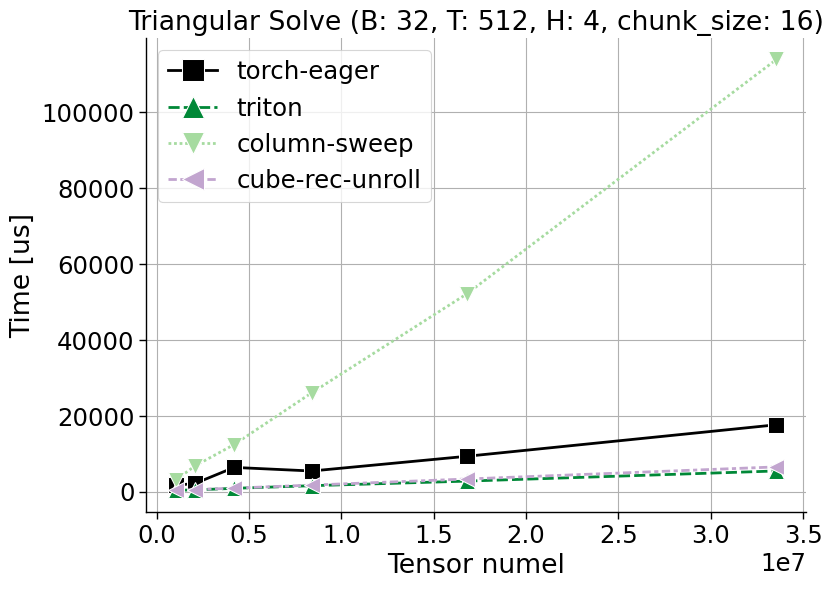

/tmp/ipykernel_1496787/1545888222.py:33: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_1496787/1545888222.py:33: UserWarning: The markers list has more values (7) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


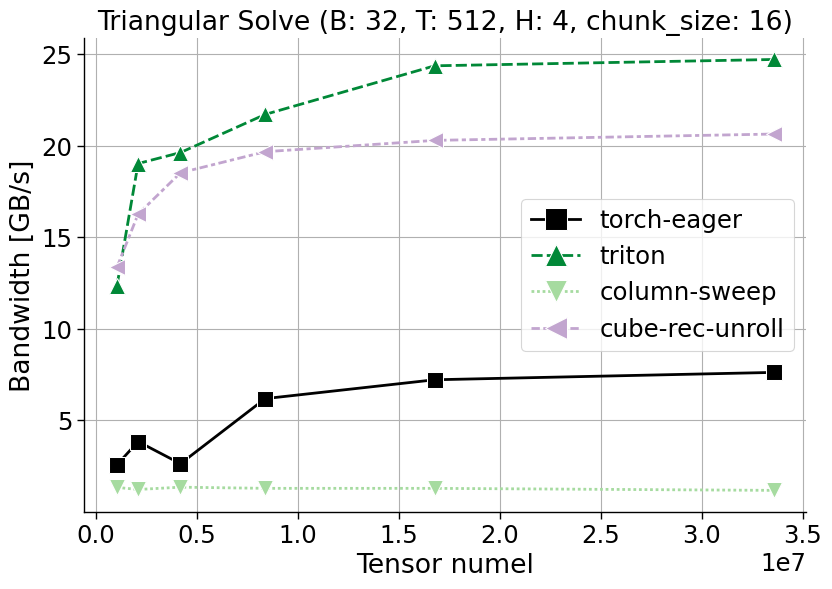

/tmp/ipykernel_1496787/1545888222.py:13: UserWarning: The markers list has more values (7) than needed (5), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)


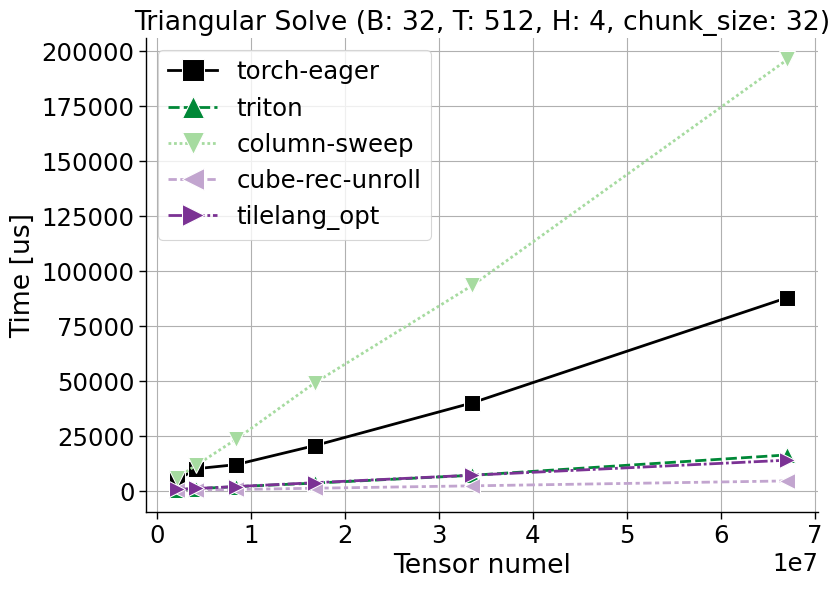

/tmp/ipykernel_1496787/1545888222.py:33: UserWarning: The markers list has more values (7) than needed (5), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


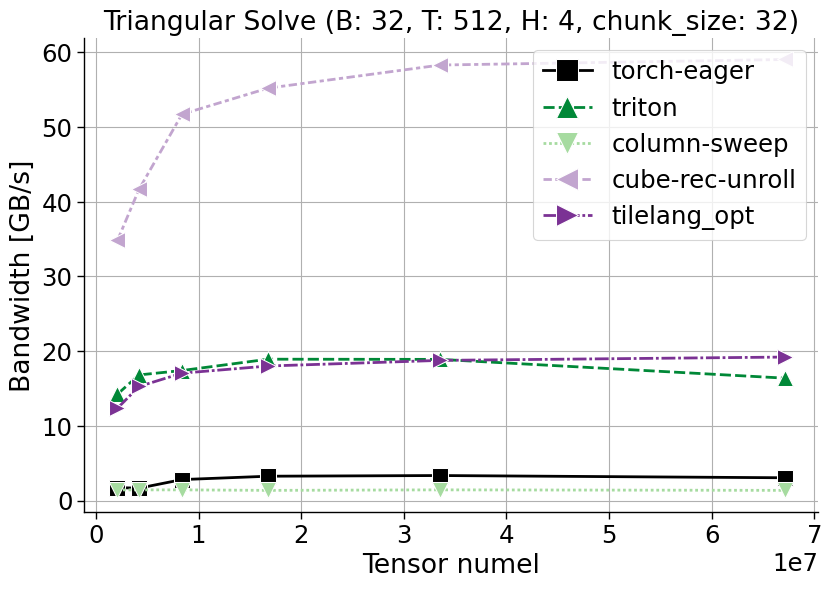

/tmp/ipykernel_1496787/1545888222.py:13: UserWarning: The markers list has more values (7) than needed (5), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)


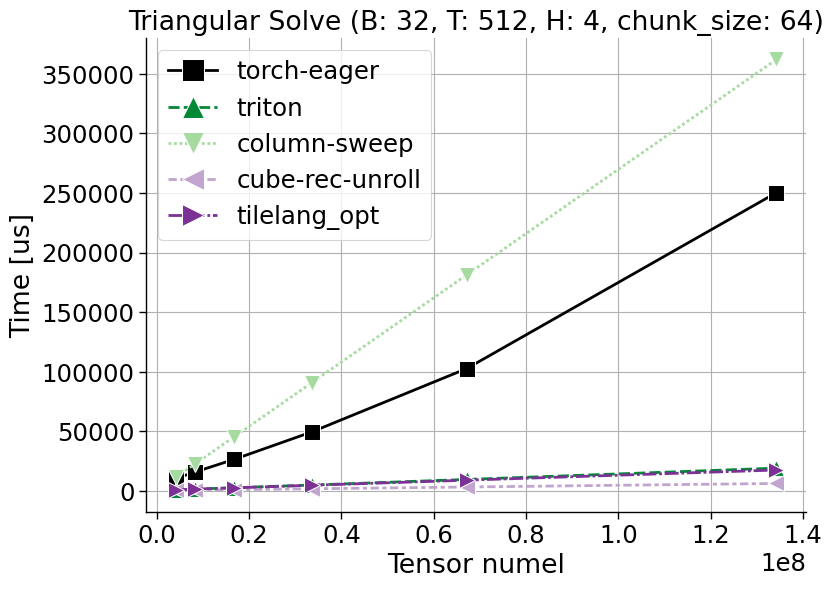

/tmp/ipykernel_1496787/1545888222.py:33: UserWarning: The markers list has more values (7) than needed (5), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


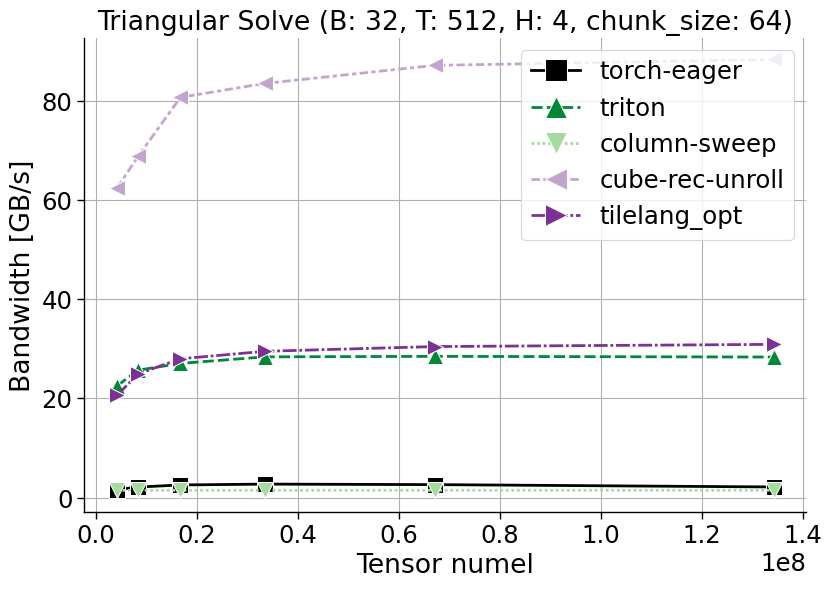

/tmp/ipykernel_1496787/1545888222.py:13: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_1496787/1545888222.py:13: UserWarning: The markers list has more values (7) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)


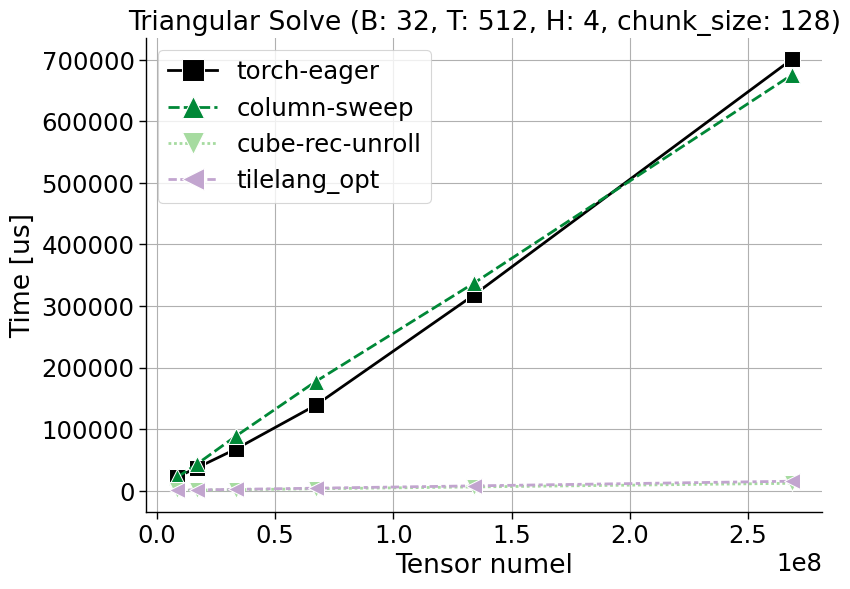

/tmp/ipykernel_1496787/1545888222.py:33: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_1496787/1545888222.py:33: UserWarning: The markers list has more values (7) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


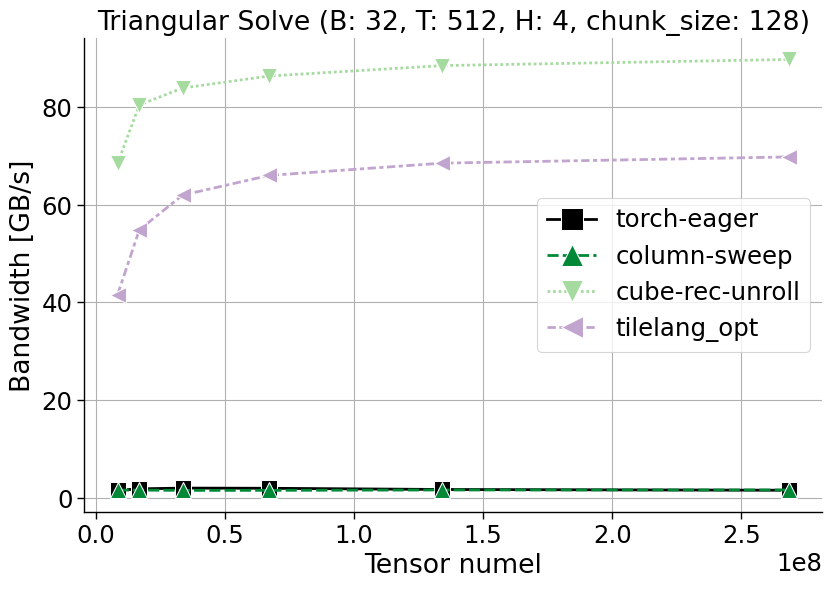

<Figure size 870x627 with 0 Axes>

In [ ]:
palette = [### Colorbrewer colors
    "black",
    "#008837",
    "#a6dba0",
    "#c2a5cf",
    "#7b3294",]


def plot_time_us(df):

    B, T, H = df["B"].unique()[0], df["T"].unique()[0], df["H"].unique()[0]
   
    ax = sns.lineplot(data=df, x='size', y='time_us', palette=palette, **_SNS_PARAMS)

    ax.set_title(f"Triangular Solve (B: {B}, T: {T}, H: {H}, chunk_size: {chunk_size})")
    ax.set_xlabel("Tensor numel")
    ax.set_ylabel("Time [us]")
    sns.despine(right = True)
    plt.legend(markerscale=_LEGEND_MARKER_SCALE)
    plt.grid()

    plt.tight_layout()

    fig = ax.get_figure()
    fig.savefig(f"figs/tri_inv_{chunk_size}_time_us.png")
    plt.show()
    plt.clf()

def plot_bw_gbps(df):

    B, T, H = df["B"].unique()[0], df["T"].unique()[0], df["H"].unique()[0]

    ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

    ax.set_title(f"Triangular Solve (B: {B}, T: {T}, H: {H}, chunk_size: {chunk_size})")
    ax.set_xlabel("Tensor numel")
    ax.set_ylabel("Bandwidth [GB/s]")
    sns.despine(right = True)
    plt.legend(markerscale=_LEGEND_MARKER_SCALE)
    plt.grid()

    plt.tight_layout()

    fig = ax.get_figure()
    fig.savefig(f"figs/tri_inv_{chunk_size}_bw_gbps.png")
    plt.show()
    plt.clf()

for chunk_size in [16, 32, 64, 128]:
    # Prepare data (bw, gelemps, etc.)
    df = pd.read_csv(f"{PREFIX_PATH}/bench_results_solve_tril_{chunk_size}.csv")
    add_stats_siso(df, 2)

    plot_time_us(df)
    plot_bw_gbps(df)